In [3]:
%pip install pandas matplotlib seaborn scikit-learn transformers ipywidgets
%pip install torch --index-url https://download.pytorch.org/whl/cu130

Looking in indexes: https://download.pytorch.org/whl/cu130


Shape: (24783, 7)


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...



Columns:
['Unnamed: 0', 'count', 'hate_speech', 'offensive_language', 'neither', 'class', 'tweet']

Data types:
Unnamed: 0             int64
count                  int64
hate_speech            int64
offensive_language     int64
neither                int64
class                  int64
tweet                 object
dtype: object

Missing values:


,missing_count
Unnamed: 0,0
count,0
hate_speech,0
offensive_language,0
neither,0
class,0
tweet,0



Duplicate rows: 0

Numeric summary:


...

,count,unique,top,freq
tweet,24783,24783,~~Ruffled | Ntac Eileen Dahlia - Beautiful col...,1



Created cleaned text column: tweet_clean


,tweet,tweet_clean
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt as a woman you shouldn t complain about cle...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dats cold tyga dwn bad for cuffin dat h...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt you ever fuck a bitch and she start...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt she look like a tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt the shit you hear about me might be true or...


,count,percentage
class,,
0,1430,5.77
1,19190,77.43
2,4163,16.80


/tmp/ipykernel_4881/3176851633.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")


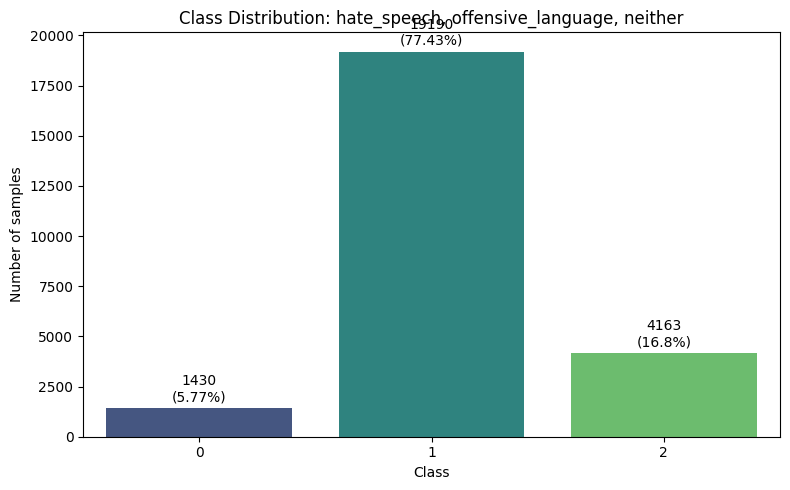


Class hate_speech - 5 examples


,class,tweet,tweet_clean
0,0,@AustinG1135 I do not like talking to you fagg...,i do not like talking to you faggot and i did ...
1,0,RT @mitchmancuso: @BrantPrintup:What straight ...,rt what straight guys take a picture of themse...
2,0,"@clinchmtn316 @sixonesixband AMERICA today, th...",america today the rule of thumb is when in dou...
3,0,"@STACCS_WNT_FOLD you tell me, coon.",you tell me coon
4,0,RT @FAAMMoverALL: This nigguh Chris Paul,rt this nigguh chris paul



Class offensive_language - 5 examples


,class,tweet,tweet_clean
0,1,Why is it everytime I go to cracker barrel the...,why is it everytime i go to cracker barrel the...
1,1,"Run that nigga, you don't want that nigga, but...",run that nigga you don t want that nigga but i...
2,1,I need a girl from Jamaica I can't fuck with t...,i need a girl from jamaica i can t fuck with t...
3,1,RT @ShadowBeatz_Inc: I know you have me blocke...,rt i know you have me blocked but next week bitch
4,1,Put ya hands up if you a Grade A bitch,put ya hands up if you a grade a bitch



Class neither - 5 examples


,class,tweet,tweet_clean
0,2,RT @chicagotribune: Chicago will not refund $7...,rt chicago will not refund million made from r...
1,2,"Sometimes, even I gotta tell these hoes to gro...",sometimes even i gotta tell these hoes to grow...
2,2,&#8216;Chillin&#8217; With My Homie Or What&#8...,chillin with my homie or what s left of him br...
3,2,.@CoryBooker is running around town delivering...,is running around town delivering food to peop...
4,2,RT @McNarstle: ...and rounding out our CNN Ebo...,rt and rounding out our cnn ebola panel tonigh...


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("./labeled_data.csv") # pd.read_csv("../data/labeled_data.csv")

# Basic overview
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumeric summary:")
display(df.describe().T)

print("\nCategorical summary:")
display(df.describe(include=["object", "category"]).T if len(df.select_dtypes(include=["object", "category"]).columns) else pd.DataFrame({"info": ["No categorical columns"]}))

# Clean text column: URLs, @mentions, hashtags, special characters
text_col = "tweet" if "tweet" in df.columns else df.select_dtypes(include=["object", "category"]).columns[0]

df[f"{text_col}_clean"] = (
    df[text_col]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"http\S+|www\.\S+", "", regex=True)   # remove URLs
    .str.replace(r"@\w+", "", regex=True)               # remove @mentions
    .str.replace(r"#(\w+)", r"\1", regex=True)          # keep hashtag word, remove #
    .str.replace(r"[^a-z\s]", " ", regex=True)          # remove special characters/numbers
    .str.replace(r"\s+", " ", regex=True)               # normalize spaces
    .str.strip()
)

print(f"\nCreated cleaned text column: {text_col}_clean")
display(df[[text_col, f"{text_col}_clean"]].head())

class_names = ["hate_speech", "offensive_language", "neither"]
target_col = "class"

# Visualize class imbalance
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

display(
    pd.DataFrame({
        "count": class_counts,
        "percentage": class_pct
    })
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x=target_col, order=class_counts.index, palette="viridis")

plt.title(f"Class Distribution: {', '.join(class_names)}")
plt.xlabel("Class")
plt.ylabel("Number of samples")

for i, cls in enumerate(class_counts.index):
    count = class_counts.loc[cls]
    pct = class_pct.loc[cls]
    ax.text(i, count + max(class_counts) * 0.01, f"{count}\n({pct}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


sample_cols = [target_col, text_col]
clean_col = f"{text_col}_clean"
if clean_col in df.columns:
    sample_cols.append(clean_col)

for cls_value in sorted(df[target_col].dropna().unique()):
    print(f"\nClass {class_names[cls_value]} - 5 examples")
    display(
        df.loc[df[target_col] == cls_value, sample_cols]
          .sample(n=min(5, (df[target_col] == cls_value).sum()), random_state=42)
          .reset_index(drop=True)
    )

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
import torch

# Keep required columns
df = df[["tweet_clean", "class"]].dropna()
X = df["tweet_clean"].astype(str)
y = df["class"].astype(int)

# Train/validation/test split (70/15/15), stratified by class
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Validation size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

# --- Compute class weights (used by sklearn models + PyTorch loss) ---
classes = np.array([0, 1, 2])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

print("\nClass weights (inverse frequency):")
for cls, w in zip(class_names, weights):
    print(f"  {cls}: {w:.4f}")

# Precompute tensor for PyTorch CrossEntropyLoss (used in Cell 4)
class_weights_tensor = torch.tensor(weights, dtype=torch.float)

# --- Baseline models with TF-IDF + class_weight='balanced' ---
models = {
    "SVM": LinearSVC(class_weight="balanced"),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, class_weight="balanced", n_jobs=None
    ),
    # RandomForest supports class_weight natively too
    "RandomForest": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", n_jobs=None
    ),
}

baseline_predictions = {}
baseline_results = []

for name, clf in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            stop_words="english",
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95
        )),
        ("clf", clf)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    baseline_predictions[name] = {y_test.name: y_test, "y_pred": y_pred}

    baseline_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted"),
    })

    print(f"\n=== {name} ===")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

Train size: 17348
Validation size: 3717
Test size: 3718

Class weights (inverse frequency):
  hate_speech: 5.7769
  offensive_language: 0.4305
  neither: 1.9844

=== SVM ===
Accuracy: 0.8959
Macro F1: 0.7401
                    precision    recall  f1-score   support

       hate_speech     0.4545    0.3972    0.4239       214
offensive_language     0.9475    0.9284    0.9379      2879
           neither     0.8070    0.9168    0.8584       625

          accuracy                         0.8959      3718
         macro avg     0.7364    0.7475    0.7401      3718
      weighted avg     0.8955    0.8959    0.8950      3718


=== LogisticRegression ===
Accuracy: 0.8677
Macro F1: 0.7363
                    precision    recall  f1-score   support

       hate_speech     0.3507    0.5981    0.4421       214
offensive_language     0.9695    0.8708    0.9175      2879
           neither     0.7705    0.9456    0.8491       625

          accuracy                         0.8677      3718
     

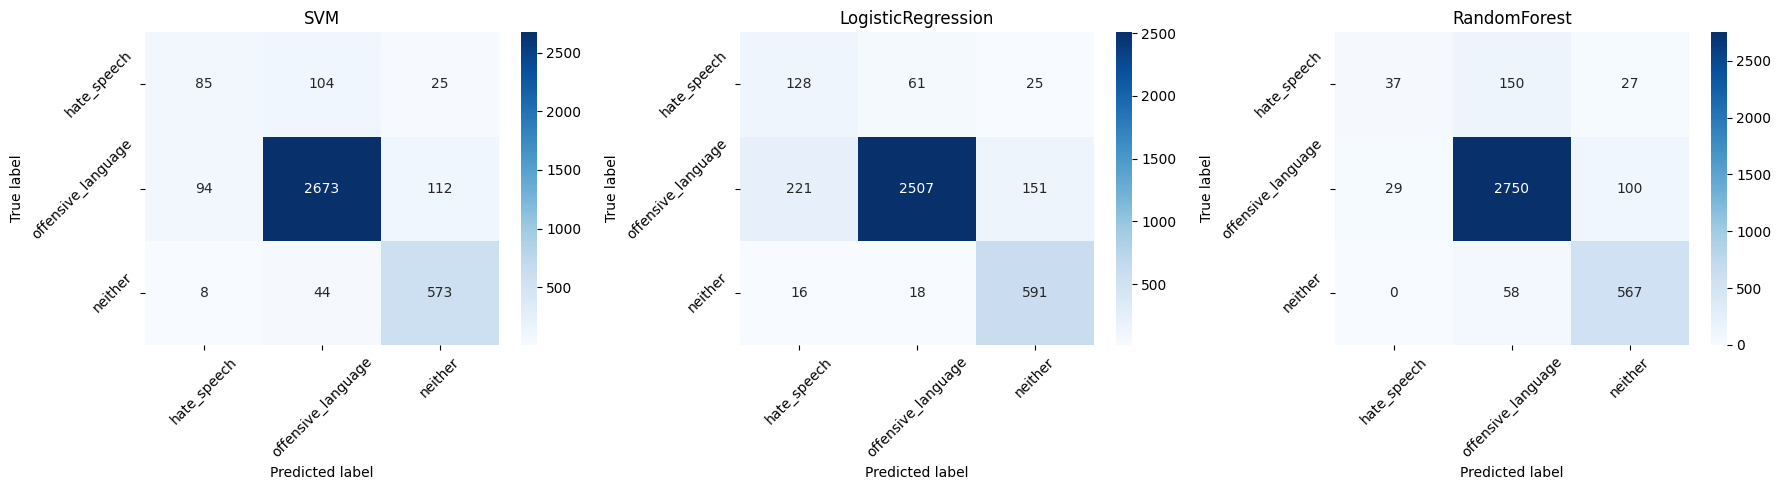


Baseline Model Comparison:


,Model,Accuracy,Macro F1,Weighted F1
0,SVM,0.895912,0.740087,0.894954
1,LogisticRegression,0.867671,0.736251,0.878628
2,RandomForest,0.902098,0.688764,0.889370



Classification Report for Best Model: SVM
                    precision    recall  f1-score   support

       hate_speech     0.4545    0.3972    0.4239       214
offensive_language     0.9475    0.9284    0.9379      2879
           neither     0.8070    0.9168    0.8584       625

          accuracy                         0.8959      3718
         macro avg     0.7364    0.7475    0.7401      3718
      weighted avg     0.8955    0.8959    0.8950      3718



In [8]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, len(models), figsize=(18, 5))

for ax, (name, results) in zip(axes, baseline_predictions.items()):
    cm = confusion_matrix(results[y_test.name], results["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_yticklabels(class_names, rotation=45)
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()


comparison_df = pd.DataFrame(baseline_results).sort_values(by="Macro F1", ascending=False).reset_index(drop=True)

print("\nBaseline Model Comparison:")
display(comparison_df)

# Classification report for best model
best_model_name = comparison_df.loc[0, "Model"]
best_results = baseline_predictions[best_model_name]

print(f"\nClassification Report for Best Model: {best_model_name}")
print(classification_report(best_results[y_test.name], best_results["y_pred"], target_names=class_names, digits=4))

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Config
model_name = "albert-base-v2"
num_labels = len(class_names)
max_length = 128
batch_size = 32
epochs = 3
lr = 1e-5

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

model.dropout.p = 0.2
model.to(device)

# Weighted loss to handle class imbalance
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts.tolist() if hasattr(texts, "tolist") else list(texts)
        self.labels = labels.tolist() if hasattr(labels, "tolist") else list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds = TweetDataset(X_train, y_train, tokenizer, max_length=max_length)
val_ds = TweetDataset(X_val, y_val, tokenizer, max_length=max_length)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

history = {
    'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
    'val_loss': [], 'val_acc': [], 'val_macro_f1': []
}

for epoch in range(epochs):
    # ---- Train ----
    model.train()

    train_loss_total = 0
    train_correct = 0
    train_total = 0
    train_preds, train_labels = [], []

    for batch_idx, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["labels"]

        optimizer.zero_grad()

        # Strip labels so HuggingFace doesn't compute its own unweighted loss
        out = model(**{k: v for k, v in batch.items() if k != "labels"})
        loss = loss_fn(out.logits, labels)

        loss.backward()
        optimizer.step()

        train_loss_total += loss.item()
        preds = torch.argmax(out.logits, dim=-1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_preds.extend(preds.cpu().numpy())
        train_labels.extend(labels.cpu().numpy())

        if (batch_idx + 1) % 50 == 0:
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f}")

    avg_train_loss = train_loss_total / len(train_loader)
    train_acc = train_correct / train_total
    train_macro_f1 = f1_score(train_labels, train_preds, average="macro")

    # ---- Validate ----
    model.eval()
    val_loss_total = 0.0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = batch["labels"]

            out = model(**{k: v for k, v in batch.items() if k != "labels"})
            loss = loss_fn(out.logits, labels)

            val_loss_total += loss.item()
            preds = torch.argmax(out.logits, dim=1)
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss_total / len(val_loader)
    val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
    val_macro_f1 = f1_score(val_labels, val_preds, average="macro")

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)
    history['train_macro_f1'].append(train_macro_f1)
    history['val_macro_f1'].append(val_macro_f1)

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Macro F1: {train_macro_f1:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Macro F1: {val_macro_f1:.4f}"
    )

Using device: cuda


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | Batch 50/543 | Loss: 0.9440
  Epoch 1 | Batch 100/543 | Loss: 0.5495
  Epoch 1 | Batch 150/543 | Loss: 0.6286
  Epoch 1 | Batch 200/543 | Loss: 0.5132
  Epoch 1 | Batch 250/543 | Loss: 0.5839
  Epoch 1 | Batch 300/543 | Loss: 0.5227
  Epoch 1 | Batch 350/543 | Loss: 0.4713
  Epoch 1 | Batch 400/543 | Loss: 0.3145
  Epoch 1 | Batch 450/543 | Loss: 1.0154
  Epoch 1 | Batch 500/543 | Loss: 0.7587
Epoch 1/3 | Train Loss: 0.6403 | Train Acc: 0.7970 | Train Macro F1: 0.6442 | Val Loss: 0.4803 | Val Acc: 0.8717 | Val Macro F1: 0.7350
  Epoch 2 | Batch 50/543 | Loss: 0.3293
  Epoch 2 | Batch 100/543 | Loss: 0.7776
  Epoch 2 | Batch 150/543 | Loss: 0.2970
  Epoch 2 | Batch 200/543 | Loss: 0.3047
  Epoch 2 | Batch 250/543 | Loss: 0.4129
  Epoch 2 | Batch 300/543 | Loss: 0.3494
  Epoch 2 | Batch 350/543 | Loss: 0.4932
  Epoch 2 | Batch 400/543 | Loss: 0.2375
  Epoch 2 | Batch 450/543 | Loss: 0.5373
  Epoch 2 | Batch 500/543 | Loss: 0.2118
Epoch 2/3 | Train Loss: 0.4734 | Train Acc: 0.

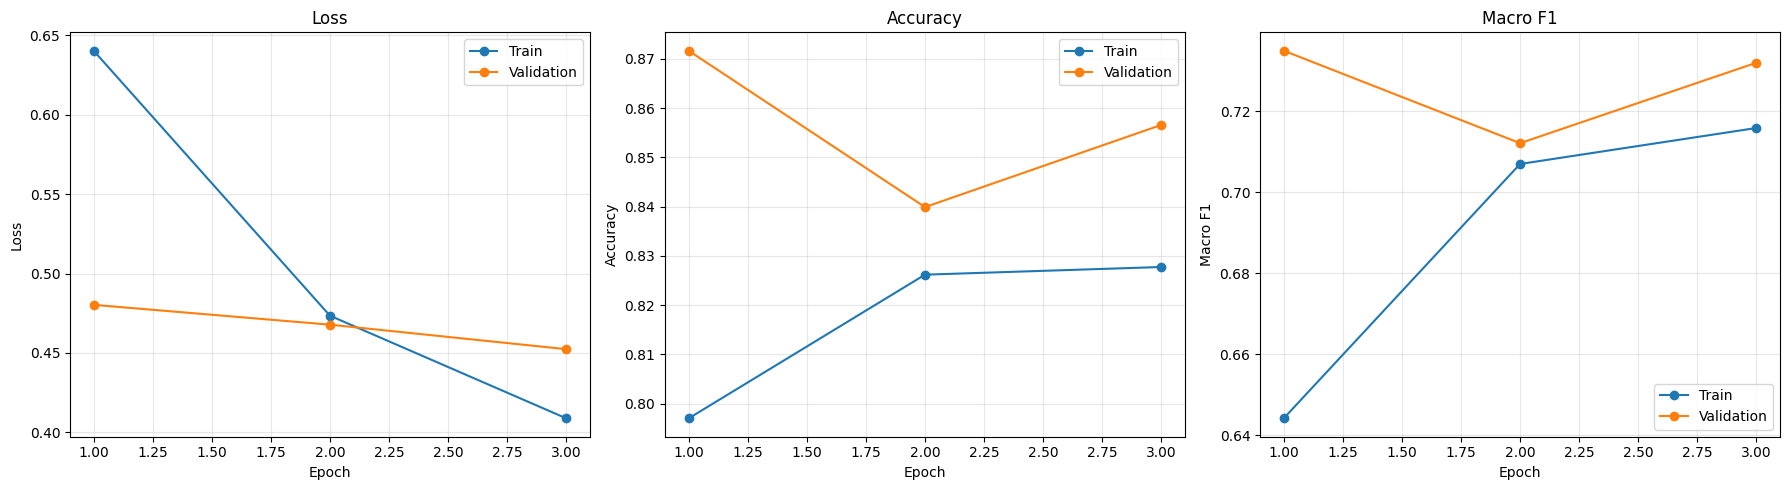


Test Accuracy: 0.8588
Test Macro F1: 0.7398

Classification Report:
                    precision    recall  f1-score   support

       hate_speech     0.2950    0.7430    0.4223       214
offensive_language     0.9774    0.8579    0.9138      2879
           neither     0.8650    0.9024    0.8833       625

          accuracy                         0.8588      3718
         macro avg     0.7125    0.8344    0.7398      3718
      weighted avg     0.9193    0.8588    0.8804      3718



In [12]:

history_df = pd.DataFrame(history)
epochs_range = range(1, len(history_df) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history_df["train_loss"], marker="o", label="Train")
axes[0].plot(epochs_range, history_df["val_loss"], marker="o", label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_df["train_acc"], marker="o", label="Train")
axes[1].plot(epochs_range, history_df["val_acc"], marker="o", label="Validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history_df["train_macro_f1"], marker="o", label="Train")
axes[2].plot(epochs_range, history_df["val_macro_f1"], marker="o", label="Validation")
axes[2].set_title("Macro F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Macro F1")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Evaluate on test set
test_ds = TweetDataset(X_test, y_test, tokenizer, max_length=max_length)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

test_preds, test_labels, test_probs = [], [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = batch["labels"]

        out = model(**{k: v for k, v in batch.items() if k != "labels"})
        probs = torch.softmax(out.logits, dim=1)

        test_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

all_preds  = np.array(test_preds)
all_labels = np.array(test_labels)
all_probs  = np.array(test_probs)

test_acc = (all_preds == all_labels).mean()
test_macro_f1 = f1_score(all_labels, all_preds, average="macro")

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

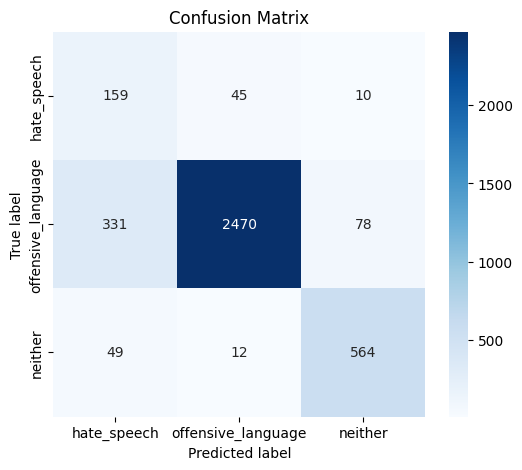

In [13]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.show()

In [14]:
# Misclassified examples
misclassified_indices = np.where(np.array(test_preds) != np.array(test_labels))[0]
misclassified_df = pd.DataFrame({
    "tweet": X_test.iloc[misclassified_indices].values,
    "true_label": [class_names[i] for i in np.array(test_labels)[misclassified_indices]],
    "predicted_label": [class_names[i] for i in np.array(test_preds)[misclassified_indices]]
})

print("\nMisclassified Examples:")
display(misclassified_df.head(10))


Misclassified Examples:


,tweet,true_label,predicted_label
0,rt half of it will be about how you became ghe...,offensive_language,neither
1,god doesn t send retards to hell,offensive_language,hate_speech
2,rt todays horoscope you re still a hoe that is...,neither,offensive_language
3,rt rt for every bad bitch there is a nigga who...,hate_speech,offensive_language
4,have u spent significant time in any ghetto or...,neither,hate_speech
5,cinco shit harder fucc nigga yee but you fucc ...,offensive_language,hate_speech
6,trenton gossman is the sexiest hillbilly i hav...,offensive_language,neither
7,ya games are you a retard,offensive_language,hate_speech
8,they already have are you retarded,offensive_language,hate_speech
9,rt not just cause of hoes go to jail cause of ...,hate_speech,offensive_language


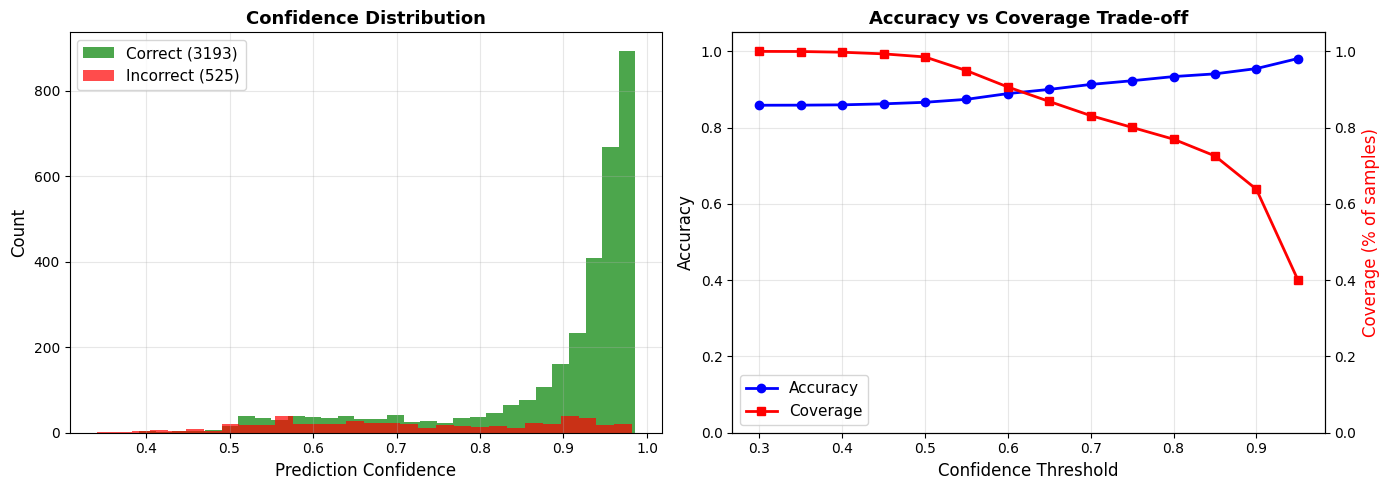

In [21]:
pred_confidence = np.max(all_probs, axis=1)
correct_mask = all_preds == all_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confidence distribution for correct vs incorrect
axes[0].hist(pred_confidence[correct_mask], bins=30, alpha=0.7,
             label=f'Correct ({correct_mask.sum()})', color='green')
axes[0].hist(pred_confidence[~correct_mask], bins=30, alpha=0.7,
             label=f'Incorrect ({(~correct_mask).sum()})', color='red')
axes[0].set_xlabel('Prediction Confidence', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Confidence Distribution', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy vs Coverage at different thresholds
thresholds = np.arange(0.3, 1.0, 0.05)
accs_at_thresh = []
coverage_at_thresh = []

for thresh in thresholds:
    mask = pred_confidence >= thresh
    if mask.sum() > 0:
        accs_at_thresh.append(accuracy_score(all_labels[mask], all_preds[mask]))
        coverage_at_thresh.append(mask.sum() / len(mask))
    else:
        accs_at_thresh.append(np.nan)
        coverage_at_thresh.append(0)

ax1 = axes[1]
ax2 = ax1.twinx()

ax1.plot(thresholds, accs_at_thresh, 'b-o', label='Accuracy', linewidth=2)
ax2.plot(thresholds, coverage_at_thresh, 'r-s', label='Coverage', linewidth=2)

ax1.set_xlabel('Confidence Threshold', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12, color='black')
ax2.set_ylabel('Coverage (% of samples)', fontsize=12, color='red')
ax1.set_title('Accuracy vs Coverage Trade-off', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=11, loc='lower left')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

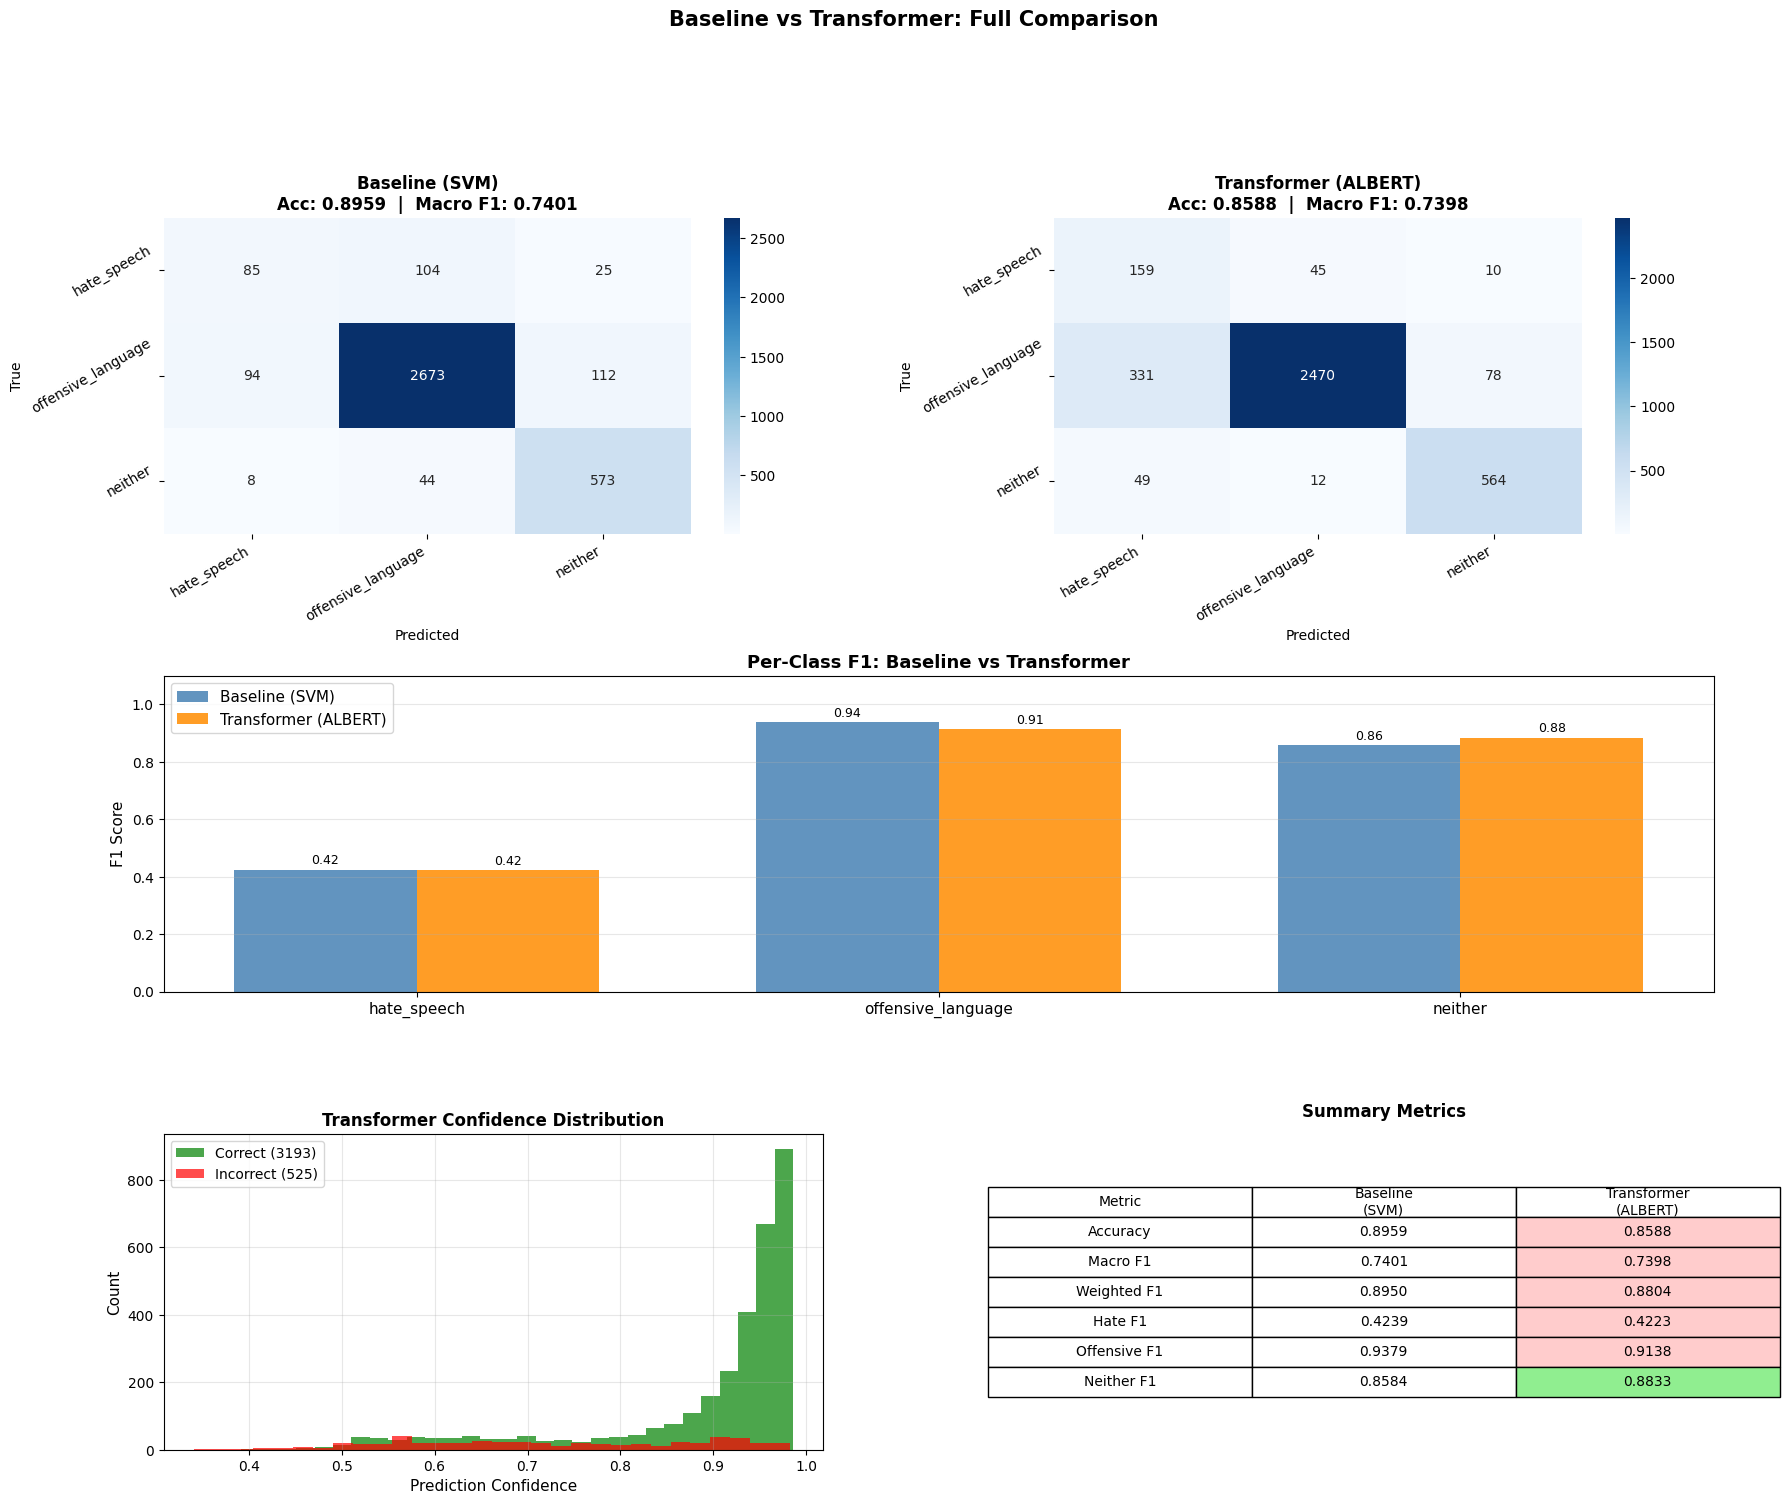

In [22]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.gridspec as gridspec

best_results = baseline_predictions[best_model_name]
baseline_preds = np.array(best_results["y_pred"])
baseline_labels = np.array(best_results[y_test.name])

# ---- Confusion matrices ----
cm_baseline   = confusion_matrix(baseline_labels, baseline_preds)
cm_transformer = confusion_matrix(all_labels, all_preds)

fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# --- Row 1: Confusion matrices ---
for col, (cm, title, preds, labels) in enumerate([
    (cm_baseline,    f"Baseline ({best_model_name})", baseline_preds, baseline_labels),
    (cm_transformer, "Transformer (ALBERT)",          all_preds,      all_labels),
]):
    ax = fig.add_subplot(gs[0, col])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="macro")
    ax.set_title(f"{title}\nAcc: {acc:.4f}  |  Macro F1: {f1:.4f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_xticklabels(class_names, rotation=30, ha="right")
    ax.set_yticklabels(class_names, rotation=30)

# --- Row 2: Per-class F1 bar chart ---
report_baseline     = classification_report(baseline_labels, baseline_preds,
                                            target_names=class_names, output_dict=True)
report_transformer  = classification_report(all_labels, all_preds,
                                            target_names=class_names, output_dict=True)

per_class_f1_baseline    = [report_baseline[c]["f1-score"]    for c in class_names]
per_class_f1_transformer = [report_transformer[c]["f1-score"] for c in class_names]

x = np.arange(len(class_names))
width = 0.35

ax = fig.add_subplot(gs[1, :])  # span full width
bars1 = ax.bar(x - width/2, per_class_f1_baseline,    width, label=f"Baseline ({best_model_name})", color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + width/2, per_class_f1_transformer, width, label="Transformer (ALBERT)",          color="darkorange", alpha=0.85)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Per-Class F1: Baseline vs Transformer", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis="y")

# --- Row 3: Confidence distribution (transformer only) + summary table ---
pred_confidence = np.max(all_probs, axis=1)
correct_mask    = all_preds == all_labels

ax_conf = fig.add_subplot(gs[2, 0])
ax_conf.hist(pred_confidence[correct_mask],  bins=30, alpha=0.7,
             label=f"Correct ({correct_mask.sum()})",   color="green")
ax_conf.hist(pred_confidence[~correct_mask], bins=30, alpha=0.7,
             label=f"Incorrect ({(~correct_mask).sum()})", color="red")
ax_conf.set_xlabel("Prediction Confidence", fontsize=11)
ax_conf.set_ylabel("Count", fontsize=11)
ax_conf.set_title("Transformer Confidence Distribution", fontsize=12, fontweight="bold")
ax_conf.legend(fontsize=10)
ax_conf.grid(True, alpha=0.3)

# --- Row 3: Summary metrics table ---
ax_tbl = fig.add_subplot(gs[2, 1])
ax_tbl.axis("off")

metrics = ["Accuracy", "Macro F1", "Weighted F1",
           "Hate F1", "Offensive F1", "Neither F1"]
baseline_vals = [
    f"{accuracy_score(baseline_labels, baseline_preds):.4f}",
    f"{f1_score(baseline_labels, baseline_preds, average='macro'):.4f}",
    f"{f1_score(baseline_labels, baseline_preds, average='weighted'):.4f}",
    f"{report_baseline['hate_speech']['f1-score']:.4f}",
    f"{report_baseline['offensive_language']['f1-score']:.4f}",
    f"{report_baseline['neither']['f1-score']:.4f}",
]
transformer_vals = [
    f"{accuracy_score(all_labels, all_preds):.4f}",
    f"{f1_score(all_labels, all_preds, average='macro'):.4f}",
    f"{f1_score(all_labels, all_preds, average='weighted'):.4f}",
    f"{report_transformer['hate_speech']['f1-score']:.4f}",
    f"{report_transformer['offensive_language']['f1-score']:.4f}",
    f"{report_transformer['neither']['f1-score']:.4f}",
]

table = ax_tbl.table(
    cellText=[[m, b, t] for m, b, t in zip(metrics, baseline_vals, transformer_vals)],
    colLabels=["Metric", f"Baseline\n({best_model_name})", "Transformer\n(ALBERT)"],
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Highlight transformer wins in green, losses in red
for row_idx, (bv, tv) in enumerate(zip(baseline_vals, transformer_vals), start=1):
    color = "lightgreen" if float(tv) >= float(bv) else "#ffcccc"
    table[row_idx, 2].set_facecolor(color)

ax_tbl.set_title("Summary Metrics", fontsize=12, fontweight="bold", pad=12)

plt.suptitle("Baseline vs Transformer: Full Comparison", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()